# Custom Candidate Function

One more possible requirement might be to automatically select the next speaker from a filtered list of agents. For this, we can set `candidate_func` parameter with a "custom candidate function" to filter down the list of potential agents for speaker selection for each turn of groupchat.

This allow us to restrict speaker selection to a specific set of agents after a given agent.

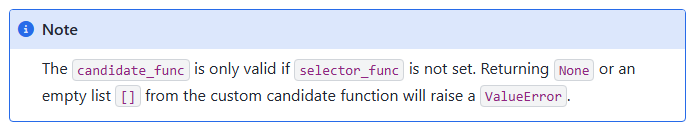

#### ***Reference URL***

https://microsoft.github.io/autogen/stable//user-guide/agentchat-user-guide/selector-group-chat.html#custom-candidate-function

In [1]:
import asyncio
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.teams import SelectorGroupChat
from autogen_agentchat.messages import TextMessage
from autogen_agentchat.conditions import TextMentionTermination,MaxMessageTermination

In [2]:
import os
from dotenv import load_dotenv

# Load API key
load_dotenv()
api_key = os.getenv('OPENAI_API_KEY')

In [3]:
# Model Client

model_client= OpenAIChatCompletionClient(model='gpt-4o')
model_client

In [4]:
# Planning Assistant Agent

planning_agent= AssistantAgent(
    name="PlanningAgent",
    description="An agent for planning tasks, this agent should be the first to engage when given a new task.",
    system_message="""
    You are a planning agent.
    Your job is to break down complex tasks into smaller, manageable subtasks.
    Your team members are:
        WebSearchAgent: Searches for information
        DataAnalystAgent: Performs calculations

    You only plan and delegate tasks - you do not execute them yourself.

    When assigning tasks, use this format:
    1. <agent> : <task>

    After all tasks are complete, summarize the findings and end with "TERMINATE".
    """,
    model_client=model_client
)

In [5]:
# Search Web Tool

def search_web_tool(query: str) -> str:
    # Simulate a web search
    if "2006-2007" in query:
        return """Here are the total points scored by Miami Heat players in the 2006-2007 season:
        Udonis Haslem: 844 points
        Dwayne Wade: 1397 points
        James Posey: 550 points
        ...
        """
    elif "2007-2008" in query:
        return "The number of total rebounds for Dwayne Wade in the Miami Heat season 2007-2008 is 214."
    elif "2008-2009" in query:
        return "The number of total rebounds for Dwayne Wade in the Miami Heat season 2008-2009 is 398."
    return "No data found."

In [6]:
# Web Search Assistant Agent

web_search_agent= AssistantAgent(
    name="WebSearchAgent",
    description="An agent for searching the web for information.",
    system_message="""
        You are a web search agent.
        Your only tool is search_web_tool - use it to find the information you need.
        You make only one search call at a time.   
        Once you have the results, you never do calculations or data analysis on them.
    """,
    model_client=model_client,
    tools= [search_web_tool]
)

In [7]:
def percentage_change_tool(start:float, end:float) -> float:
    '''Calculate percentage change'''
    
    if start == 0:
        return 0
    return ((end - start) / start) * 100

In [8]:
# Data Analyst Assistant Agent

data_analyst_agent= AssistantAgent(
    name="DataAnalystAgent",
    description="An agent for performing calculations and data analysis.",
    system_message="""
        You are a data analyst agent.
        Given the tasks you have been assigned, you should analyze the data and provide results using the tools provided.
        If you have not seen the data, ask for it.
    """,
    model_client=model_client,
    tools= [percentage_change_tool]
)

In [9]:
# Termination Condition
from autogen_agentchat.conditions import TextMentionTermination, MaxMessageTermination

text_mention_termination= TextMentionTermination(text="TERMINATE")
max_message_termination= MaxMessageTermination(max_messages=20)

combined_termination= text_mention_termination | max_message_termination

In [10]:
selector_prompt='''

Select an agent to perform the task.

{roles}

current conversation history :
{history}

Read the above conversation, then select an agent from {participants} to perform the next task.
Make sure that the planning agent has assigned task before other agents start working.
Only select one agent.
'''

### Custom Candidate Function
One more possible requirement might be to automatically select the next speaker from a filtered list of agents. For this, we can set `candidate_func` parameter with a "custom candidate function" to filter down the list of potential agents for speaker selection for each turn of groupchat.

This allow us to restrict speaker selection to a specific set of agents after a given agent.

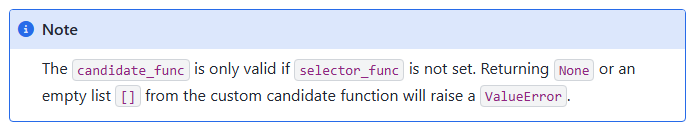

In [13]:
from autogen_agentchat.messages import BaseAgentEvent, BaseChatMessage
from typing import Sequence, List

In [14]:
def candidate_func(messages: Sequence[BaseAgentEvent | BaseChatMessage]) -> List[str]:
    # keep planning_agent first one to plan out the tasks
    if messages[-1].source == "user":
        return [planning_agent.name]

    # if previous agent is planning_agent and if it explicitely asks for web_search_agent
    # or data_analyst_agent or both (in-case of re-planning or re-assignment of tasks)
    # then return those specific agents
    last_message = messages[-1]
    if last_message.source == planning_agent.name:
        participants = []
        if web_search_agent.name in last_message.to_text():
            participants.append(web_search_agent.name)
        if data_analyst_agent.name in last_message.to_text():
            participants.append(data_analyst_agent.name)
        if participants:
            return participants  # SelectorGroupChat will select from the remaining two agents.

    # we can assume that the task is finished once the web_search_agent
    # and data_analyst_agent have took their turns, thus we send
    # in planning_agent to terminate the chat
    previous_set_of_agents = set(message.source for message in messages)
    if web_search_agent.name in previous_set_of_agents and data_analyst_agent.name in previous_set_of_agents:
        return [planning_agent.name]

    # if no-conditions are met then return all the agents
    return [planning_agent.name, web_search_agent.name, data_analyst_agent.name]


# Reset the previous team and run the chat again with the selector function.
# await team.reset()
team = SelectorGroupChat(
    [planning_agent, web_search_agent, data_analyst_agent],
    model_client=model_client,
    termination_condition=combined_termination,
    candidate_func=candidate_func,
)


In [15]:
task= "Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?"
task

'Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?'

In [16]:
from autogen_agentchat.ui import Console

await Console(team.run_stream(task=task))

---------- TextMessage (user) ----------
Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?
---------- TextMessage (PlanningAgent) ----------
To address this question, we need to break it down into two main tasks:

1. Identify the Miami Heat player with the highest points in the 2006-2007 season.
2. Calculate the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons.

Here are the tasks assigned to the respective agents:

1. WebSearchAgent: Identify the Miami Heat player with the highest points in the 2006-2007 season.
2. WebSearchAgent: Find the total rebounds for the identified player in the 2007-2008 and 2008-2009 seasons.
3. DataAnalystAgent: Calculate the percentage change in total rebounds between the 2007-2008 and 2008-2009 seasons for the identified player.
---------- ToolCallRequestEvent (WebSearchAgent) ----------
[Func

TaskResult(messages=[TextMessage(id='2f2be931-fcb1-4804-9d2a-6100b9ab8efd', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 20, 9, 1, 28, 442571, tzinfo=datetime.timezone.utc), content='Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?', type='TextMessage'), TextMessage(id='51e97a01-69a9-445e-bb25-e03ac368099c', source='PlanningAgent', models_usage=RequestUsage(prompt_tokens=161, completion_tokens=165), metadata={}, created_at=datetime.datetime(2025, 7, 20, 9, 1, 32, 135818, tzinfo=datetime.timezone.utc), content='To address this question, we need to break it down into two main tasks:\n\n1. Identify the Miami Heat player with the highest points in the 2006-2007 season.\n2. Calculate the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons.\n\nHere are the tasks assigned to the respective age

#### Structured Output

In [ ]:
TaskResult(
    messages=[
        TextMessage(id='2f2be931-fcb1-4804-9d2a-6100b9ab8efd', 
                    source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 20, 9, 1, 28, 442571, tzinfo=datetime.timezone.utc), 
                    content='Who was the Miami Heat player with the highest point in the 2006-2007 season, and what was the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons?', type='TextMessage'), 
                    
                    TextMessage(id='51e97a01-69a9-445e-bb25-e03ac368099c', 
                                source='PlanningAgent', models_usage=RequestUsage(prompt_tokens=161, completion_tokens=165), metadata={}, created_at=datetime.datetime(2025, 7, 20, 9, 1, 32, 135818, tzinfo=datetime.timezone.utc), 
                                content='To address this question, we need to break it down into two main tasks:\n\n1. Identify the Miami Heat player with the highest points in the 2006-2007 season.\n2. Calculate the percentage change in his total rebounds between the 2007-2008 and 2008-2009 seasons.\n\nHere are the tasks assigned to the respective agents:\n\n1. WebSearchAgent: Identify the Miami Heat player with the highest points in the 2006-2007 season.\n2. WebSearchAgent: Find the total rebounds for the identified player in the 2007-2008 and 2008-2009 seasons.\n3. DataAnalystAgent: Calculate the percentage change in total rebounds between the 2007-2008 and 2008-2009 seasons for the identified player.', type='TextMessage'), 
                                
                    ToolCallRequestEvent(id='b77c210a-2af5-4eff-9730-6bc5a44324b7', 
                                         source='WebSearchAgent', models_usage=RequestUsage(prompt_tokens=321, completion_tokens=25), metadata={}, created_at=datetime.datetime(2025, 7, 20, 9, 1, 33, 848523, tzinfo=datetime.timezone.utc), 
                                         content=[FunctionCall(id='call_ep4GmgpxrSAlTeVJtKxLcTAd', arguments='{"query":"Miami Heat highest scorer 2006-2007 season"}', name='search_web_tool')], type='ToolCallRequestEvent'), 
                                         
                    ToolCallExecutionEvent(id='720c936b-af57-4998-aea4-933371d85ad4', 
                                           source='WebSearchAgent', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 20, 9, 1, 33, 851522, tzinfo=datetime.timezone.utc), 
                                           content=[FunctionExecutionResult(content='Here are the total points scored by Miami Heat players in the 2006-2007 season:\n        Udonis Haslem: 844 points\n        Dwayne Wade: 1397 points\n        James Posey: 550 points\n        ...\n        ', name='search_web_tool', call_id='call_ep4GmgpxrSAlTeVJtKxLcTAd', is_error=False)], type='ToolCallExecutionEvent'), 
                                           
                    ToolCallSummaryMessage(id='c3a69628-a96f-459b-b23e-ef1f4051008f', 
                                           source='WebSearchAgent', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 20, 9, 1, 33, 851522, tzinfo=datetime.timezone.utc), 
                                           content='Here are the total points scored by Miami Heat players in the 2006-2007 season:\n        Udonis Haslem: 844 points\n        Dwayne Wade: 1397 points\n        James Posey: 550 points\n        ...\n        ', type='ToolCallSummaryMessage', tool_calls=[FunctionCall(id='call_ep4GmgpxrSAlTeVJtKxLcTAd', arguments='{"query":"Miami Heat highest scorer 2006-2007 season"}', name='search_web_tool')], results=[FunctionExecutionResult(content='Here are the total points scored by Miami Heat players in the 2006-2007 season:\n        Udonis Haslem: 844 points\n        Dwayne Wade: 1397 points\n        James Posey: 550 points\n        ...\n        ', name='search_web_tool', call_id='call_ep4GmgpxrSAlTeVJtKxLcTAd', is_error=False)]), 
                                           
                    ThoughtEvent(id='b91e0906-8100-4dc6-a922-74aef8a3b077', 
                                 source='DataAnalystAgent', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 20, 9, 1, 37, 605411, tzinfo=datetime.timezone.utc), 
                                 content="The Miami Heat player with the highest points in the 2006-2007 season was Dwyane Wade with 1,397 points.\n\n" \
                                         "Next, we need to find Dwyane Wade's total rebounds for the 2007-2008 and 2008-2009 seasons.", type='ThoughtEvent'), 
                                 
                    ToolCallRequestEvent(id='4c376d3d-5dd8-4305-adc6-6a8adbd45b05', 
                                         source='DataAnalystAgent', models_usage=RequestUsage(prompt_tokens=383, completion_tokens=100), metadata={}, created_at=datetime.datetime(2025, 7, 20, 9, 1, 37, 605411, tzinfo=datetime.timezone.utc), 
                                         content=[FunctionCall(id='call_w6TzceT6hD2Tw9U2miUI8Qtj', arguments='{"start": 4.2, "end": 5.0}', name='percentage_change_tool')], type='ToolCallRequestEvent'), 
                                         
                    ToolCallExecutionEvent(id='e680d647-033f-46a2-85ad-66a0768f6773', 
                                           source='DataAnalystAgent', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 20, 9, 1, 37, 607412, tzinfo=datetime.timezone.utc), 
                                           content=[FunctionExecutionResult(content='19.047619047619044', name='percentage_change_tool', call_id='call_w6TzceT6hD2Tw9U2miUI8Qtj', is_error=False)], type='ToolCallExecutionEvent'), 
                                           
                    ToolCallSummaryMessage(id='10b05668-830d-43d8-975f-ae5856b797a4', 
                                           source='DataAnalystAgent', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 20, 9, 1, 37, 607412, tzinfo=datetime.timezone.utc), 
                                           content='19.047619047619044', type='ToolCallSummaryMessage', tool_calls=[FunctionCall(id='call_w6TzceT6hD2Tw9U2miUI8Qtj', arguments='{"start": 4.2, "end": 5.0}', name='percentage_change_tool')], results=[FunctionExecutionResult(content='19.047619047619044', name='percentage_change_tool', call_id='call_w6TzceT6hD2Tw9U2miUI8Qtj', is_error=False)]), 
                                           
                    TextMessage(id='b94deab2-91d9-4f0d-a002-466bdf4ebbe4', 
                                source='PlanningAgent', models_usage=RequestUsage(prompt_tokens=407, completion_tokens=77), metadata={}, created_at=datetime.datetime(2025, 7, 20, 9, 1, 39, 68535, tzinfo=datetime.timezone.utc), 
                                content="Based on the information gathered:\n\n" \
                                        "1. The Miami Heat player with the highest points in the 2006-2007 season was Dwyane Wade, with 1,397 points.\n" \
                                        "2. The percentage change in Dwyane Wade's total rebounds between the 2007-2008 and 2008-2009 seasons is approximately 19.05%.\n\n" \
                                        "TERMINATE", 
                                type='TextMessage')], 
           
    stop_reason="Text 'TERMINATE' mentioned")